# 047. Breast Cancer Classification and Segmentation Using Deep Learning on Ultrasound Images

**Dataset:** BUSI Breast Ultrasound Images  
**Classification:** ResNet18 pipeline retained unchanged  
**Segmentation comparison:** U-Net vs Attention U-Net vs DeepLabV3-ResNet50

### Segmentation experiment
- U-Net: baseline
- Attention U-Net: attention-gated skip connections
- DeepLabV3-ResNet50: atrous convolution + ASPP

All segmentation models use the same split, augmentation, loss, optimizer settings, epochs, threshold, Dice and IoU evaluation.
Multiple masks for the same ultrasound image are OR-merged.


## 1. Imports & Configuration

In [ ]:
import json
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

%matplotlib inline
sns.set_theme(style="whitegrid")

# Paths (notebook lives in project root)
ROOT = Path.cwd()
DATA_DIR = ROOT / "Dataset_BUSI_with_GT"
OUTPUT_DIR = ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
SPLIT_DIR = OUTPUT_DIR / "splits"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, FIGURE_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["benign", "malignant", "normal"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

# Shared
SEED = 42
IMG_SIZE = 224
NUM_WORKERS = 0
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Classification
CLS_BATCH_SIZE = 32
CLS_EPOCHS = 15
CLS_LR = 1e-4
CLS_WEIGHT_DECAY = 1e-4
CLS_MODEL = "resnet18"  # resnet18 | densenet121 | efficientnet_b0

# Segmentation
SEG_BATCH_SIZE = 8
SEG_EPOCHS = 20
SEG_LR = 1e-4
SEG_WEIGHT_DECAY = 1e-4
SEG_INCLUDE_NORMAL = False

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")
    


set_seed(SEED)
DEVICE = get_device()
print(f"ROOT={ROOT}")
print(f"Device={DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU={torch.cuda.get_device_name(0)}")


ROOT=d:\HarryK\UNSW\comp9444\proj
Device=cuda
GPU=NVIDIA GeForce RTX 5070 Ti


c:\Users\Admin\miniconda3\envs\unsw\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Utilities (metrics & plotting)

In [5]:
def plot_history(history: Dict[str, List[float]], title: str, ylabel: str = "value", out_path: Path | None = None):
    plt.figure(figsize=(8, 5))
    for key, values in history.items():
        plt.plot(range(1, len(values) + 1), values, label=key, marker="o", markersize=3)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if out_path is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
    plt.show()


def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix", out_path: Path | None = None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    if out_path is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150)
    plt.show()


def classification_metrics(y_true, y_pred, class_names):
    report = classification_report(
        y_true, y_pred, target_names=list(class_names), digits=4, zero_division=0, output_dict=True
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "report": report,
    }

## 3. Dataset: discovery, preprocessing, augmentation, split

- Pair each ultrasound image with its ground-truth mask(s) (OR-merge multi-masks)
- Stratified **70% / 15% / 15%** train / val / test split
- Classification augmentations: flip, rotation, brightness/contrast
- Segmentation: paired geometric augmentations on image + mask

In [6]:
@dataclass
class Sample:
    image_path: Path
    mask_paths: List[Path]
    label: int
    class_name: str


def discover_samples(data_dir: Path = DATA_DIR) -> List[Sample]:
    samples: List[Sample] = []
    for class_name in CLASS_NAMES:
        class_dir = data_dir / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")
        images = sorted(p for p in class_dir.glob("*.png") if "_mask" not in p.name)
        for img_path in images:
            stem = img_path.stem
            mask_paths = sorted(class_dir.glob(f"{stem}_mask*.png"))
            if not mask_paths:
                continue
            samples.append(
                Sample(
                    image_path=img_path,
                    mask_paths=mask_paths,
                    label=CLASS_TO_IDX[class_name],
                    class_name=class_name,
                )
            )
    return samples


def stratified_split(samples: List[Sample], seed: int = SEED) -> Dict[str, List[Sample]]:
    labels = [s.label for s in samples]
    train_val, test = train_test_split(samples, test_size=TEST_RATIO, random_state=seed, stratify=labels)
    val_ratio_adj = VAL_RATIO / (1.0 - TEST_RATIO)
    labels_tv = [s.label for s in train_val]
    train, val = train_test_split(train_val, test_size=val_ratio_adj, random_state=seed, stratify=labels_tv)
    return {"train": train, "val": val, "test": test}


def save_split(split: Dict[str, List[Sample]], out_dir: Path = SPLIT_DIR) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        split_name: [
            {
                "image": str(s.image_path),
                "masks": [str(m) for m in s.mask_paths],
                "label": s.label,
                "class_name": s.class_name,
            }
            for s in items
        ]
        for split_name, items in split.items()
    }
    path = out_dir / "split.json"
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return path


def load_split(path: Path = SPLIT_DIR / "split.json") -> Dict[str, List[Sample]]:
    payload = json.loads(path.read_text(encoding="utf-8"))
    return {
        split_name: [
            Sample(
                image_path=Path(item["image"]),
                mask_paths=[Path(m) for m in item["masks"]],
                label=item["label"],
                class_name=item["class_name"],
            )
            for item in items
        ]
        for split_name, items in payload.items()
    }


def load_rgb(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")


def load_combined_mask(mask_paths: List[Path], size: Tuple[int, int]) -> Image.Image:
    combined = np.zeros((size[1], size[0]), dtype=np.uint8)
    for mp in mask_paths:
        m = np.array(Image.open(mp).convert("L").resize(size, Image.NEAREST))
        combined = np.maximum(combined, (m > 127).astype(np.uint8) * 255)
    return Image.fromarray(combined, mode="L")


class ClassificationAugment:
    def __init__(self, img_size: int = IMG_SIZE):
        self.train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.eval_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, image: Image.Image, train: bool) -> torch.Tensor:
        return self.train_tf(image) if train else self.eval_tf(image)


class SegmentationAugment:
    def __init__(self, img_size: int = IMG_SIZE, train: bool = True):
        self.img_size = img_size
        self.train = train
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, image: Image.Image, mask: Image.Image) -> Tuple[torch.Tensor, torch.Tensor]:
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        if self.train:
            if random.random() < 0.5:
                image = image.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() < 0.2:
                image = image.transpose(Image.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
            angle = random.uniform(-15, 15)
            image = image.rotate(angle, resample=Image.BILINEAR)
            mask = mask.rotate(angle, resample=Image.NEAREST)
            if random.random() < 0.5:
                image = transforms.functional.adjust_brightness(image, random.uniform(0.8, 1.2))
            if random.random() < 0.5:
                image = transforms.functional.adjust_contrast(image, random.uniform(0.8, 1.2))
        img_t = self.normalize(transforms.functional.to_tensor(image))
        mask_t = torch.from_numpy((np.array(mask) > 127).astype(np.float32)).unsqueeze(0)
        return img_t, mask_t


class BUSIClassificationDataset(Dataset):
    def __init__(self, samples: List[Sample], train: bool = False):
        self.samples = samples
        self.train = train
        self.augment = ClassificationAugment()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return self.augment(load_rgb(s.image_path), train=self.train), s.label


class BUSISegmentationDataset(Dataset):
    def __init__(self, samples: List[Sample], train: bool = False, include_normal: bool = SEG_INCLUDE_NORMAL):
        self.samples = samples if include_normal else [s for s in samples if s.class_name != "normal"]
        self.train = train
        self.augment = SegmentationAugment(train=train)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        image = load_rgb(s.image_path)
        mask = load_combined_mask(s.mask_paths, image.size)
        return self.augment(image, mask)

### Explore dataset & create split

Total samples: 780
Class counts: {'benign': 437, 'malignant': 210, 'normal': 133}


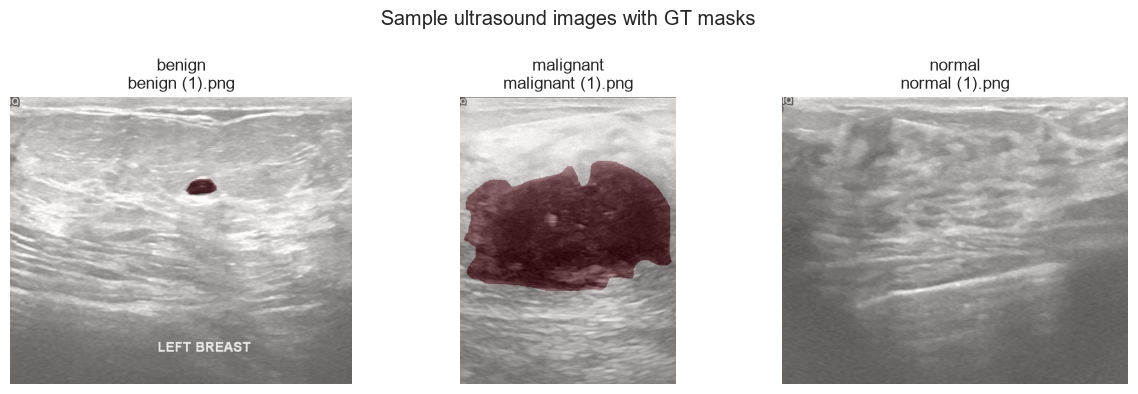

Created new split -> d:\HarryK\UNSW\comp9444\proj\outputs\splits\split.json
  train: 545 -> {'benign': 305, 'malignant': 147, 'normal': 93}
  val: 118 -> {'benign': 66, 'normal': 20, 'malignant': 32}
  test: 117 -> {'benign': 66, 'malignant': 31, 'normal': 20}


In [8]:
samples = discover_samples()
print(f"Total samples: {len(samples)}")
print("Class counts:", dict(Counter(s.class_name for s in samples)))

# Show one example per class
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, class_name in zip(axes, CLASS_NAMES):
    s = next(x for x in samples if x.class_name == class_name)
    img = load_rgb(s.image_path)
    mask = load_combined_mask(s.mask_paths, img.size)
    ax.imshow(img)
    ax.imshow(np.array(mask), cmap="Reds", alpha=0.35)
    ax.set_title(f"{class_name}\n{s.image_path.name}")
    ax.axis("off")
plt.suptitle("Sample ultrasound images with GT masks")
plt.tight_layout()
plt.show()

split_path = SPLIT_DIR / "split.json"
if split_path.exists():
    split = load_split(split_path)
    print(f"Loaded existing split from {split_path}")
else:
    split = stratified_split(samples)
    save_split(split)
    print(f"Created new split -> {split_path}")

for name, items in split.items():
    print(f"  {name}: {len(items)} -> {dict(Counter(s.class_name for s in items))}")

## 4. Models: Classifier (ResNet/DenseNet/EfficientNet) + U-Net

In [11]:
def build_classifier(name: str = "resnet18", num_classes: int = 3) -> nn.Module:
    name = name.lower()
    if name == "resnet18":
        try:
            weights = models.ResNet18_Weights.DEFAULT
        except Exception:
            weights = None
        backbone = models.resnet18(weights=weights)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        return backbone
    if name == "densenet121":
        try:
            weights = models.DenseNet121_Weights.DEFAULT
        except Exception:
            weights = None
        backbone = models.densenet121(weights=weights)
        backbone.classifier = nn.Linear(backbone.classifier.in_features, num_classes)
        return backbone
    if name in {"efficientnet_b0", "efficientnet-b0"}:
        try:
            weights = models.EfficientNet_B0_Weights.DEFAULT
        except Exception:
            weights = None
        backbone = models.efficientnet_b0(weights=weights)
        backbone.classifier[1] = nn.Linear(backbone.classifier[1].in_features, num_classes)
        return backbone
    raise ValueError(f"Unsupported classifier: {name}")


# ============================================================
# Segmentation models
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """Baseline U-Net used by the original notebook."""
    def __init__(self, in_channels: int = 3, out_channels: int = 1, base: int = 32):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.enc4 = ConvBlock(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = ConvBlock(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = ConvBlock(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)



class AttentionGate(nn.Module):
    """Attention gate for filtering encoder skip-connection features."""
    def __init__(self, gating_channels, skip_channels, inter_channels):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(skip_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.psi = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        if g1.shape[-2:] != x1.shape[-2:]:
            g1 = F.interpolate(
                g1,
                size=x1.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        alpha = self.psi(g1 + x1)
        return x * alpha


class AttentionUNet(nn.Module):
    """Attention U-Net for binary breast lesion segmentation."""
    def __init__(self, in_channels=3, out_channels=1, base=32):
        super().__init__()

        self.enc1 = ConvBlock(in_channels, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.enc4 = ConvBlock(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.att4 = AttentionGate(base * 8, base * 8, base * 4)
        self.dec4 = ConvBlock(base * 16, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.att3 = AttentionGate(base * 4, base * 4, base * 2)
        self.dec3 = ConvBlock(base * 8, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.att2 = AttentionGate(base * 2, base * 2, base)
        self.dec2 = ConvBlock(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.att1 = AttentionGate(base, base, max(base // 2, 1))
        self.dec1 = ConvBlock(base * 2, base)

        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        u4 = self.up4(b)
        a4 = self.att4(u4, e4)
        d4 = self.dec4(torch.cat([u4, a4], dim=1))

        u3 = self.up3(d4)
        a3 = self.att3(u3, e3)
        d3 = self.dec3(torch.cat([u3, a3], dim=1))

        u2 = self.up2(d3)
        a2 = self.att2(u2, e2)
        d2 = self.dec2(torch.cat([u2, a2], dim=1))

        u1 = self.up1(d2)
        a1 = self.att1(u1, e1)
        d1 = self.dec1(torch.cat([u1, a1], dim=1))

        return self.head(d1)


def build_deeplabv3(num_classes: int = 1, pretrained: bool = True) -> nn.Module:
    """
    DeepLabV3 with a ResNet50 backbone for binary lesion segmentation.

    pretrained=True:
        Tries to load torchvision COCO-pretrained DeepLabV3 weights.
        If weights cannot be downloaded/found, automatically falls back to
        a randomly initialized model so the notebook can still run.
    """
    if pretrained:
        try:
            weights = models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
            model = models.segmentation.deeplabv3_resnet50(
                weights=weights,
                aux_loss=False,
            )
            print("Loaded pretrained DeepLabV3-ResNet50 weights.")
        except Exception as exc:
            print(f"Warning: pretrained DeepLabV3 weights unavailable: {exc}")
            print("Falling back to randomly initialized DeepLabV3-ResNet50.")
            model = models.segmentation.deeplabv3_resnet50(
                weights=None,
                weights_backbone=None,
                num_classes=21,
                aux_loss=False,
            )
    else:
        model = models.segmentation.deeplabv3_resnet50(
            weights=None,
            weights_backbone=None,
            num_classes=21,
            aux_loss=False,
        )

    # Torchvision DeepLabV3 classifier ends with a 1x1 Conv2d.
    # Replace the 21-class output with one binary lesion channel.
    last_conv = model.classifier[-1]
    model.classifier[-1] = nn.Conv2d(
        last_conv.in_channels,
        num_classes,
        kernel_size=1,
    )
    return model


def get_seg_logits(model: nn.Module, images: torch.Tensor) -> torch.Tensor:
    """
    Makes U-Net and torchvision segmentation models share one interface.
    U-Net returns Tensor.
    DeepLabV3 returns OrderedDict({'out': Tensor}).
    """
    output = model(images)
    if isinstance(output, dict):
        output = output["out"]
    return output


class DiceBCELoss(nn.Module):
    """
    BCEWithLogits + soft Dice loss.
    Dice is computed per image, then averaged across the batch.
    """
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)

        dims = (1, 2, 3)
        intersection = (probs * targets).sum(dim=dims)
        denominator = probs.sum(dim=dims) + targets.sum(dim=dims)

        dice_loss = 1.0 - (
            (2.0 * intersection + self.smooth) /
            (denominator + self.smooth)
        )
        return bce + dice_loss.mean()


def batch_dice_scores(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> torch.Tensor:
    """Return one Dice score per image."""
    preds = (torch.sigmoid(logits) > threshold).float()
    dims = (1, 2, 3)
    intersection = (preds * targets).sum(dim=dims)
    denominator = preds.sum(dim=dims) + targets.sum(dim=dims)
    return (2.0 * intersection + eps) / (denominator + eps)


def batch_iou_scores(
    logits: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
) -> torch.Tensor:
    """Return one IoU score per image."""
    preds = (torch.sigmoid(logits) > threshold).float()
    dims = (1, 2, 3)
    intersection = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims) - intersection
    return (intersection + eps) / (union + eps)


print("Classifier:", CLS_MODEL)
print(build_classifier(CLS_MODEL))
print("\nU-Net params:",
      sum(p.numel() for p in UNet().parameters()) / 1e6, "M")


Classifier: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## 5. Classification Training (ResNet18 -> benign / malignant / normal)

In [ ]:
def make_cls_loaders(split):
    datasets = {
        "train": BUSIClassificationDataset(split["train"], train=True),
        "val": BUSIClassificationDataset(split["val"], train=False),
        "test": BUSIClassificationDataset(split["test"], train=False),
    }
    return {
        name: DataLoader(
            ds,
            batch_size=CLS_BATCH_SIZE,
            shuffle=(name == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )
        for name, ds in datasets.items()
    }


@torch.no_grad()
def evaluate_cls(model, loader, criterion):
    model.eval()
    total_loss, y_true, y_pred = 0.0, [], []
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * images.size(0)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
    avg_loss = total_loss / max(len(loader.dataset), 1)
    acc = sum(int(a == b) for a, b in zip(y_true, y_pred)) / max(len(y_true), 1)
    return avg_loss, acc, y_true, y_pred


set_seed(SEED)
cls_loaders = make_cls_loaders(split)
print(f"[Classification] train={len(split['train'])} val={len(split['val'])} test={len(split['test'])}")

cls_model = build_classifier(CLS_MODEL, num_classes=len(CLASS_NAMES)).to(DEVICE)
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = torch.optim.AdamW(cls_model.parameters(), lr=CLS_LR, weight_decay=CLS_WEIGHT_DECAY)
cls_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(cls_optimizer, T_max=CLS_EPOCHS)

cls_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = -1.0
best_cls_path = CHECKPOINT_DIR / "best_classifier.pth"

for epoch in range(1, CLS_EPOCHS + 1):
    cls_model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(cls_loaders["train"], desc=f"Cls Epoch {epoch}/{CLS_EPOCHS}")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        cls_optimizer.zero_grad()
        logits = cls_model(images)
        loss = cls_criterion(logits, labels)
        loss.backward()
        cls_optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=loss.item(), acc=correct / max(total, 1))

    cls_scheduler.step()
    train_loss = running_loss / max(total, 1)
    train_acc = correct / max(total, 1)
    val_loss, val_acc, _, _ = evaluate_cls(cls_model, cls_loaders["val"], cls_criterion)
    cls_history["train_loss"].append(train_loss)
    cls_history["val_loss"].append(val_loss)
    cls_history["train_acc"].append(train_acc)
    cls_history["val_acc"].append(val_acc)
    print(f"  train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "model_name": CLS_MODEL,
                "state_dict": cls_model.state_dict(),
                "val_acc": best_val_acc,
                "epoch": epoch,
                "class_names": CLASS_NAMES,
            },
            best_cls_path,
        )
        print(f"  saved best classifier (val_acc={best_val_acc:.4f})")

### Classification evaluation

In [ ]:
plot_history(
    {"train_loss": cls_history["train_loss"], "val_loss": cls_history["val_loss"]},
    "Classification Loss", ylabel="Loss", out_path=FIGURE_DIR / "classification_loss.png",
)
plot_history(
    {"train_acc": cls_history["train_acc"], "val_acc": cls_history["val_acc"]},
    "Classification Accuracy", ylabel="Accuracy", out_path=FIGURE_DIR / "classification_accuracy.png",
)

ckpt = torch.load(best_cls_path, map_location=DEVICE, weights_only=False)
cls_model.load_state_dict(ckpt["state_dict"])
test_loss, test_acc, y_true, y_pred = evaluate_cls(cls_model, cls_loaders["test"], cls_criterion)
cls_metrics = classification_metrics(y_true, y_pred, CLASS_NAMES)
plot_confusion(
    y_true, y_pred, CLASS_NAMES,
    title="Classification Confusion Matrix (Test)",
    out_path=FIGURE_DIR / "classification_confusion.png",
)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f"TEST accuracy={cls_metrics['accuracy']:.4f} | macro_f1={cls_metrics['macro_f1']:.4f}")

cls_results = {
    "best_val_acc": best_val_acc,
    "test_loss": test_loss,
    "test_accuracy": cls_metrics["accuracy"],
    "macro_f1": cls_metrics["macro_f1"],
    "weighted_f1": cls_metrics["weighted_f1"],
    "classification_report": cls_metrics["report"],
    "history": cls_history,
}
(OUTPUT_DIR / "classification_results.json").write_text(json.dumps(cls_results, indent=2), encoding="utf-8")

## 6. Segmentation Comparison: U-Net vs DeepLabV3-ResNet50

This section focuses only on segmentation.

### Experimental design
Both models use exactly the same:
- BUSI train / validation / test split
- benign + malignant images (normal excluded by default)
- OR-merged ground-truth masks
- image size and paired augmentation
- Dice + BCE loss
- AdamW optimizer
- cosine learning-rate schedule
- number of epochs
- threshold = 0.5
- per-image mean Dice and IoU evaluation

**Important:** DeepLabV3 is pretrained by default when torchvision weights are available.  
This should be stated clearly in the report because the U-Net baseline is trained from scratch.


In [12]:
def make_seg_loaders(split):
    datasets = {
        "train": BUSISegmentationDataset(
            split["train"], train=True, include_normal=SEG_INCLUDE_NORMAL
        ),
        "val": BUSISegmentationDataset(
            split["val"], train=False, include_normal=SEG_INCLUDE_NORMAL
        ),
        "test": BUSISegmentationDataset(
            split["test"], train=False, include_normal=SEG_INCLUDE_NORMAL
        ),
    }

    return {
        name: DataLoader(
            ds,
            batch_size=SEG_BATCH_SIZE,
            shuffle=(name == "train"),
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )
        for name, ds in datasets.items()
    }


@torch.no_grad()
def evaluate_seg(model, loader, criterion):
    """Evaluate with mean per-image Dice and IoU."""
    model.eval()

    total_loss = 0.0
    all_dice = []
    all_iou = []
    n = 0

    for images, masks in loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = get_seg_logits(model, images)
        bs = images.size(0)

        total_loss += criterion(logits, masks).item() * bs
        all_dice.extend(batch_dice_scores(logits, masks).cpu().tolist())
        all_iou.extend(batch_iou_scores(logits, masks).cpu().tolist())
        n += bs

    avg_loss = total_loss / max(n, 1)
    mean_dice = float(np.mean(all_dice)) if all_dice else 0.0
    mean_iou = float(np.mean(all_iou)) if all_iou else 0.0

    return avg_loss, mean_dice, mean_iou


def train_segmentation_model(
    model: nn.Module,
    model_name: str,
    loaders,
    epochs: int = SEG_EPOCHS,
    lr: float = SEG_LR,
    weight_decay: float = SEG_WEIGHT_DECAY,
):
    """
    Generic trainer used for BOTH U-Net and DeepLabV3.
    The best checkpoint is selected by validation Dice.
    """
    model = model.to(DEVICE)
    criterion = DiceBCELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_dice": [],
        "val_dice": [],
        "val_iou": [],
    }

    best_val_dice = -1.0
    safe_name = model_name.lower().replace("-", "_").replace(" ", "_")
    best_path = CHECKPOINT_DIR / f"best_{safe_name}.pth"

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        train_dice_scores = []
        total = 0

        pbar = tqdm(
            loaders["train"],
            desc=f"{model_name} Epoch {epoch}/{epochs}",
        )

        for images, masks in pbar:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            logits = get_seg_logits(model, images)
            loss = criterion(logits, masks)

            loss.backward()
            optimizer.step()

            bs = images.size(0)
            running_loss += loss.item() * bs
            total += bs

            dice_values = batch_dice_scores(
                logits.detach(), masks
            ).cpu().tolist()
            train_dice_scores.extend(dice_values)

            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                dice=f"{np.mean(dice_values):.4f}",
            )

        scheduler.step()

        train_loss = running_loss / max(total, 1)
        train_dice = (
            float(np.mean(train_dice_scores))
            if train_dice_scores else 0.0
        )

        val_loss, val_dice, val_iou = evaluate_seg(
            model,
            loaders["val"],
            criterion,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        print(
            f"[{model_name}] "
            f"train_loss={train_loss:.4f} "
            f"train_dice={train_dice:.4f} | "
            f"val_loss={val_loss:.4f} "
            f"val_dice={val_dice:.4f} "
            f"val_iou={val_iou:.4f}"
        )

        if val_dice > best_val_dice:
            best_val_dice = val_dice

            torch.save(
                {
                    "model_name": model_name,
                    "state_dict": model.state_dict(),
                    "val_dice": best_val_dice,
                    "epoch": epoch,
                    "img_size": IMG_SIZE,
                },
                best_path,
            )

            print(
                f"Saved best {model_name} "
                f"(val_dice={best_val_dice:.4f})"
            )

    return {
        "model": model,
        "model_name": model_name,
        "history": history,
        "best_val_dice": best_val_dice,
        "best_path": best_path,
        "criterion": criterion,
    }


def load_best_segmentation_model(
    model_name: str,
    checkpoint_path: Path,
):
    """Rebuild a segmentation model and load its saved checkpoint."""
    name = model_name.lower()

    if "deeplab" in name:
        # Do not re-download pretrained weights when loading checkpoint.
        model = build_deeplabv3(num_classes=1, pretrained=False)
    elif "attention" in name:
        model = AttentionUNet(in_channels=3, out_channels=1, base=32)
    elif "unet" in name or "u-net" in name:
        model = UNet(in_channels=3, out_channels=1, base=32)
    else:
        raise ValueError(f"Unknown segmentation model: {model_name}")

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(checkpoint["state_dict"])
    model = model.to(DEVICE)
    model.eval()

    return model


set_seed(SEED)
seg_loaders = make_seg_loaders(split)

print(
    f"[Segmentation] "
    f"train={len(seg_loaders['train'].dataset)} "
    f"val={len(seg_loaders['val'].dataset)} "
    f"test={len(seg_loaders['test'].dataset)}"
)


[Segmentation] train=452 val=98 test=97


### 6.1 Train baseline: U-Net


UNet Epoch 1/20: 100%|██████████| 57/57 [00:05<00:00,  9.82it/s, dice=0.2074, loss=1.4652]


[UNet] train_loss=1.4530 train_dice=0.1990 | val_loss=1.3472 val_dice=0.4051 val_iou=0.2879
Saved best UNet (val_dice=0.4051)


UNet Epoch 2/20: 100%|██████████| 57/57 [00:05<00:00, 11.23it/s, dice=0.4510, loss=1.3002]


[UNet] train_loss=1.2689 train_dice=0.4314 | val_loss=1.2240 val_dice=0.5008 val_iou=0.3765
Saved best UNet (val_dice=0.5008)


UNet Epoch 3/20: 100%|██████████| 57/57 [00:05<00:00, 11.23it/s, dice=0.5321, loss=1.1212]


...

[UNet] train_loss=0.9375 train_dice=0.7031 | val_loss=0.9404 val_dice=0.6849 val_iou=0.5726


UNet Epoch 19/20: 100%|██████████| 57/57 [00:05<00:00, 11.24it/s, dice=0.7450, loss=0.9400]


[UNet] train_loss=0.9346 train_dice=0.6948 | val_loss=0.9368 val_dice=0.6846 val_iou=0.5716


UNet Epoch 20/20: 100%|██████████| 57/57 [00:05<00:00, 11.38it/s, dice=0.6962, loss=0.9083]


[UNet] train_loss=0.9334 train_dice=0.7082 | val_loss=0.9361 val_dice=0.6879 val_iou=0.5756


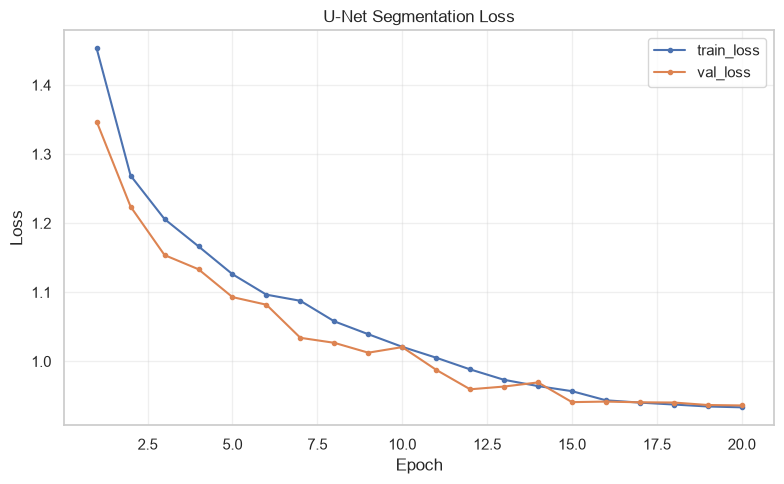

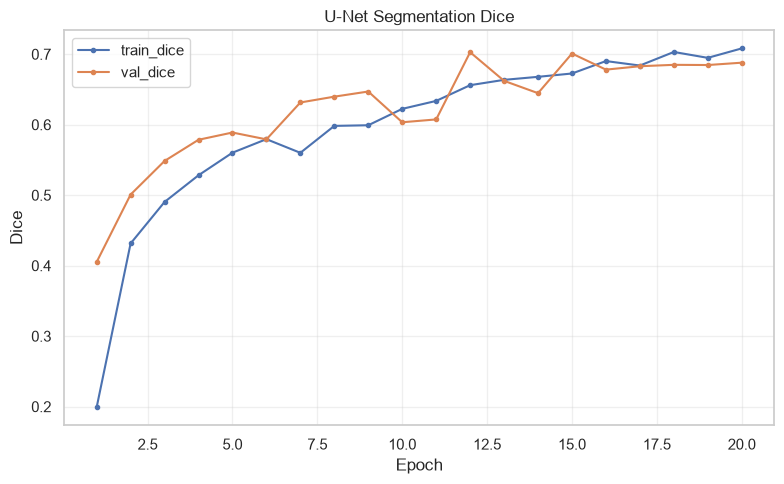

In [13]:
set_seed(SEED)

unet_experiment = train_segmentation_model(
    model=UNet(in_channels=3, out_channels=1, base=32),
    model_name="UNet",
    loaders=seg_loaders,
)

plot_history(
    {
        "train_loss": unet_experiment["history"]["train_loss"],
        "val_loss": unet_experiment["history"]["val_loss"],
    },
    "U-Net Segmentation Loss",
    ylabel="Loss",
    out_path=FIGURE_DIR / "unet_segmentation_loss.png",
)

plot_history(
    {
        "train_dice": unet_experiment["history"]["train_dice"],
        "val_dice": unet_experiment["history"]["val_dice"],
    },
    "U-Net Segmentation Dice",
    ylabel="Dice",
    out_path=FIGURE_DIR / "unet_segmentation_dice.png",
)


### 6.2 Train comparison model: Attention U-Net

Attention U-Net adds attention gates to U-Net skip connections so the model can emphasize lesion-relevant regions.


AttentionUNet Epoch 1/20: 100%|██████████| 57/57 [00:05<00:00, 10.35it/s, dice=0.5651, loss=1.3096]


[AttentionUNet] train_loss=1.3828 train_dice=0.3418 | val_loss=1.2878 val_dice=0.4318 val_iou=0.3168
Saved best AttentionUNet (val_dice=0.4318)


AttentionUNet Epoch 2/20: 100%|██████████| 57/57 [00:05<00:00, 10.41it/s, dice=0.6393, loss=1.0061]


[AttentionUNet] train_loss=1.2437 train_dice=0.4621 | val_loss=1.2327 val_dice=0.4717 val_iou=0.3544
Saved best AttentionUNet (val_dice=0.4717)


AttentionUNet Epoch 3/20: 100%|██████████| 57/57 [00:05<00:00, 10.50it/s, dice=0.5128, loss=1.1979]


...

[AttentionUNet] train_loss=0.8987 train_dice=0.6952 | val_loss=0.9131 val_dice=0.6675 val_iou=0.5538


AttentionUNet Epoch 19/20: 100%|██████████| 57/57 [00:05<00:00, 10.47it/s, dice=0.5209, loss=0.9976]


[AttentionUNet] train_loss=0.9008 train_dice=0.6870 | val_loss=0.9045 val_dice=0.6767 val_iou=0.5614


AttentionUNet Epoch 20/20: 100%|██████████| 57/57 [00:05<00:00, 10.47it/s, dice=0.3736, loss=1.1166]


[AttentionUNet] train_loss=0.8969 train_dice=0.6927 | val_loss=0.8984 val_dice=0.6937 val_iou=0.5811


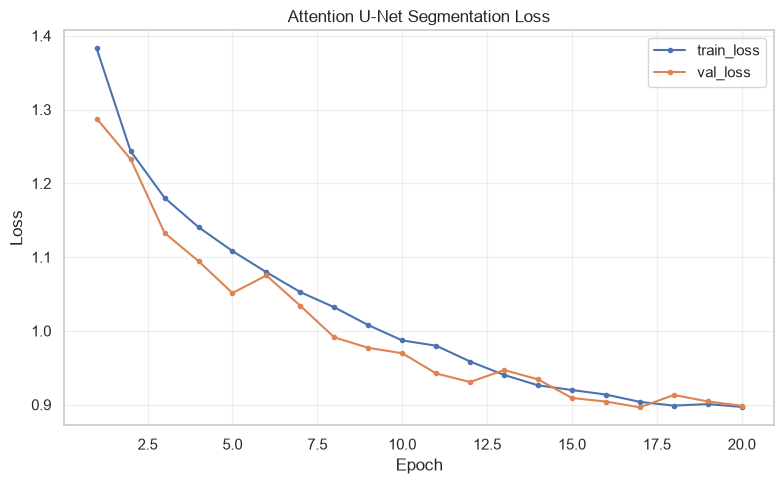

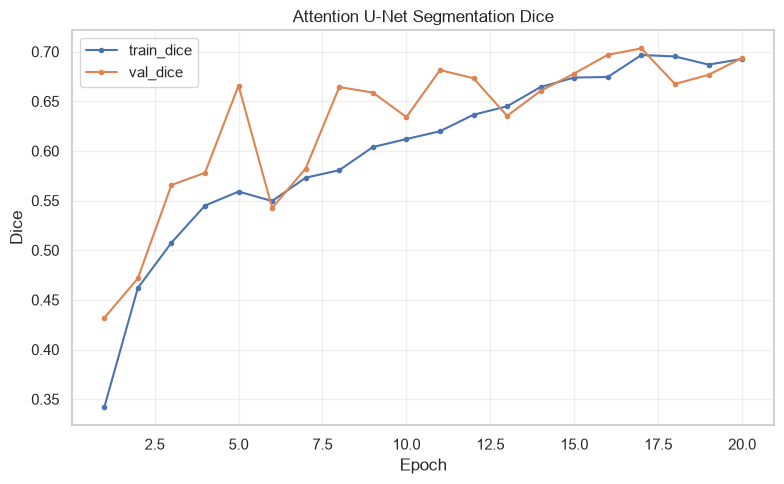

In [14]:
set_seed(SEED)

attention_unet_experiment = train_segmentation_model(
    model=AttentionUNet(
        in_channels=3,
        out_channels=1,
        base=32,
    ),
    model_name="AttentionUNet",
    loaders=seg_loaders,
)

plot_history(
    {
        "train_loss": attention_unet_experiment["history"]["train_loss"],
        "val_loss": attention_unet_experiment["history"]["val_loss"],
    },
    "Attention U-Net Segmentation Loss",
    ylabel="Loss",
    out_path=FIGURE_DIR / "attention_unet_segmentation_loss.png",
)

plot_history(
    {
        "train_dice": attention_unet_experiment["history"]["train_dice"],
        "val_dice": attention_unet_experiment["history"]["val_dice"],
    },
    "Attention U-Net Segmentation Dice",
    ylabel="Dice",
    out_path=FIGURE_DIR / "attention_unet_segmentation_dice.png",
)


### 6.3 Train comparison model: DeepLabV3-ResNet50

DeepLabV3-ResNet50 uses atrous convolution and ASPP for multi-scale contextual segmentation.
The final output head is changed to one binary lesion-mask channel.


Falling back to randomly initialized DeepLabV3-ResNet50.


DeepLabV3-ResNet50 Epoch 1/20: 100%|██████████| 57/57 [00:07<00:00,  7.57it/s, dice=0.2792, loss=1.1228]


[DeepLabV3-ResNet50] train_loss=1.2864 train_dice=0.2500 | val_loss=1.2064 val_dice=0.3242 val_iou=0.2221
Saved best DeepLabV3-ResNet50 (val_dice=0.3242)


DeepLabV3-ResNet50 Epoch 2/20: 100%|██████████| 57/57 [00:07<00:00,  7.66it/s, dice=0.3716, loss=1.0374]


[DeepLabV3-ResNet50] train_loss=1.0870 train_dice=0.3219 | val_loss=0.9679 val_dice=0.3720 val_iou=0.2718
Saved best DeepLabV3-ResNet50 (val_dice=0.3720)


...

[DeepLabV3-ResNet50] train_loss=0.4787 train_dice=0.7144 | val_loss=0.4213 val_dice=0.7343 val_iou=0.6239
Saved best DeepLabV3-ResNet50 (val_dice=0.7343)


DeepLabV3-ResNet50 Epoch 19/20: 100%|██████████| 57/57 [00:07<00:00,  7.68it/s, dice=0.6562, loss=0.5847]


[DeepLabV3-ResNet50] train_loss=0.4653 train_dice=0.7224 | val_loss=0.4162 val_dice=0.7316 val_iou=0.6209


DeepLabV3-ResNet50 Epoch 20/20: 100%|██████████| 57/57 [00:07<00:00,  7.64it/s, dice=0.6917, loss=0.4814]


[DeepLabV3-ResNet50] train_loss=0.4592 train_dice=0.7258 | val_loss=0.4220 val_dice=0.7320 val_iou=0.6211


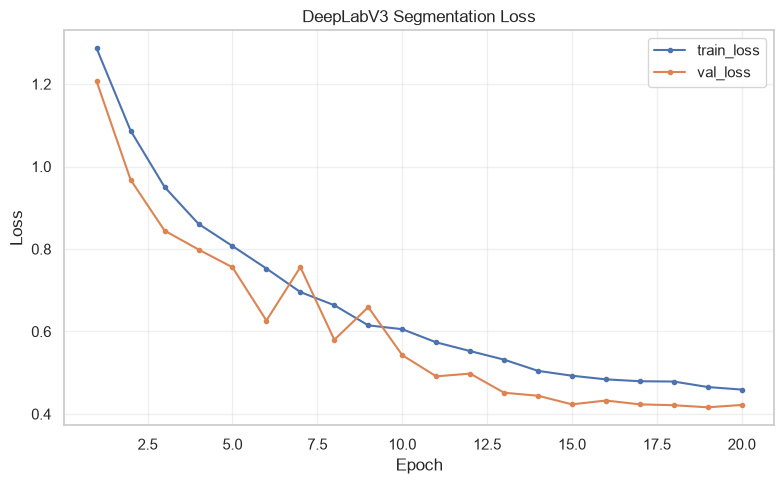

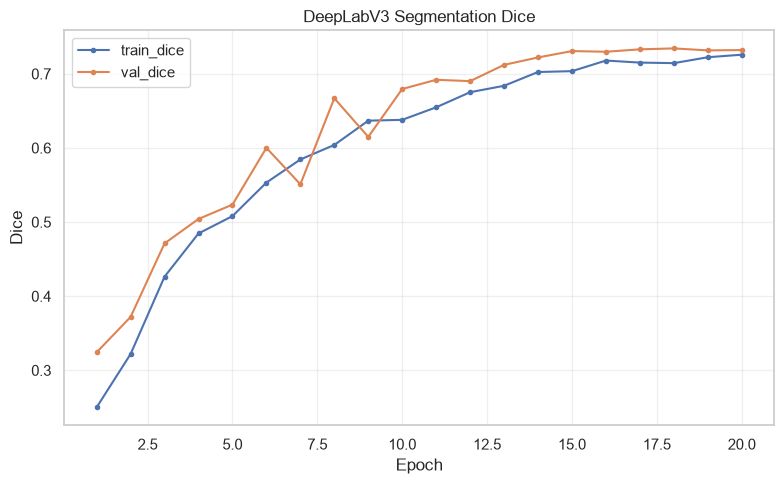

In [15]:
set_seed(SEED)

deeplab_experiment = train_segmentation_model(
    model=build_deeplabv3(
        num_classes=1,
        pretrained=True,
    ),
    model_name="DeepLabV3-ResNet50",
    loaders=seg_loaders,
)

plot_history(
    {
        "train_loss": deeplab_experiment["history"]["train_loss"],
        "val_loss": deeplab_experiment["history"]["val_loss"],
    },
    "DeepLabV3 Segmentation Loss",
    ylabel="Loss",
    out_path=FIGURE_DIR / "deeplabv3_segmentation_loss.png",
)

plot_history(
    {
        "train_dice": deeplab_experiment["history"]["train_dice"],
        "val_dice": deeplab_experiment["history"]["val_dice"],
    },
    "DeepLabV3 Segmentation Dice",
    ylabel="Dice",
    out_path=FIGURE_DIR / "deeplabv3_segmentation_dice.png",
)


## 7. Segmentation Evaluation and Model Comparison

The best validation-Dice checkpoint for each model is loaded before test evaluation.


In [16]:
def evaluate_best_experiment(experiment, loaders):
    model = load_best_segmentation_model(
        experiment["model_name"],
        experiment["best_path"],
    )

    criterion = DiceBCELoss()

    test_loss, test_dice, test_iou = evaluate_seg(
        model,
        loaders["test"],
        criterion,
    )

    return {
        "model": experiment["model_name"],
        "best_val_dice": experiment["best_val_dice"],
        "test_loss": test_loss,
        "test_dice": test_dice,
        "test_iou": test_iou,
        "checkpoint": str(experiment["best_path"]),
    }


unet_result = evaluate_best_experiment(
    unet_experiment,
    seg_loaders,
)

attention_unet_result = evaluate_best_experiment(
    attention_unet_experiment,
    seg_loaders,
)

deeplab_result = evaluate_best_experiment(
    deeplab_experiment,
    seg_loaders,
)

segmentation_comparison = [
    unet_result,
    attention_unet_result,
    deeplab_result,
]

print("\n=== Segmentation Model Comparison ===")
print(
    f"{'Model':<25} "
    f"{'Best Val Dice':>15} "
    f"{'Test Dice':>12} "
    f"{'Test IoU':>12} "
    f"{'Test Loss':>12}"
)
print("-" * 82)

for r in segmentation_comparison:
    print(
        f"{r['model']:<25} "
        f"{r['best_val_dice']:>15.4f} "
        f"{r['test_dice']:>12.4f} "
        f"{r['test_iou']:>12.4f} "
        f"{r['test_loss']:>12.4f}"
    )

best_seg_result = max(
    segmentation_comparison,
    key=lambda x: x["test_dice"],
)

print(
    f"\nBest segmentation model by Test Dice: "
    f"{best_seg_result['model']} "
    f"(Dice={best_seg_result['test_dice']:.4f}, "
    f"IoU={best_seg_result['test_iou']:.4f})"
)

(OUTPUT_DIR / "segmentation_comparison.json").write_text(
    json.dumps(segmentation_comparison, indent=2),
    encoding="utf-8",
)



=== Segmentation Model Comparison ===
Model                       Best Val Dice    Test Dice     Test IoU    Test Loss
----------------------------------------------------------------------------------
UNet                               0.7028       0.6856       0.5731       0.9404
AttentionUNet                      0.7033       0.6969       0.5811       0.8800
DeepLabV3-ResNet50                 0.7343       0.7093       0.6069       0.4991

Best segmentation model by Test Dice: DeepLabV3-ResNet50 (Dice=0.7093, IoU=0.6069)


861

### 7.1 Qualitative comparison

Each row shows:

**Ultrasound → Ground Truth → U-Net → Attention U-Net → DeepLabV3**


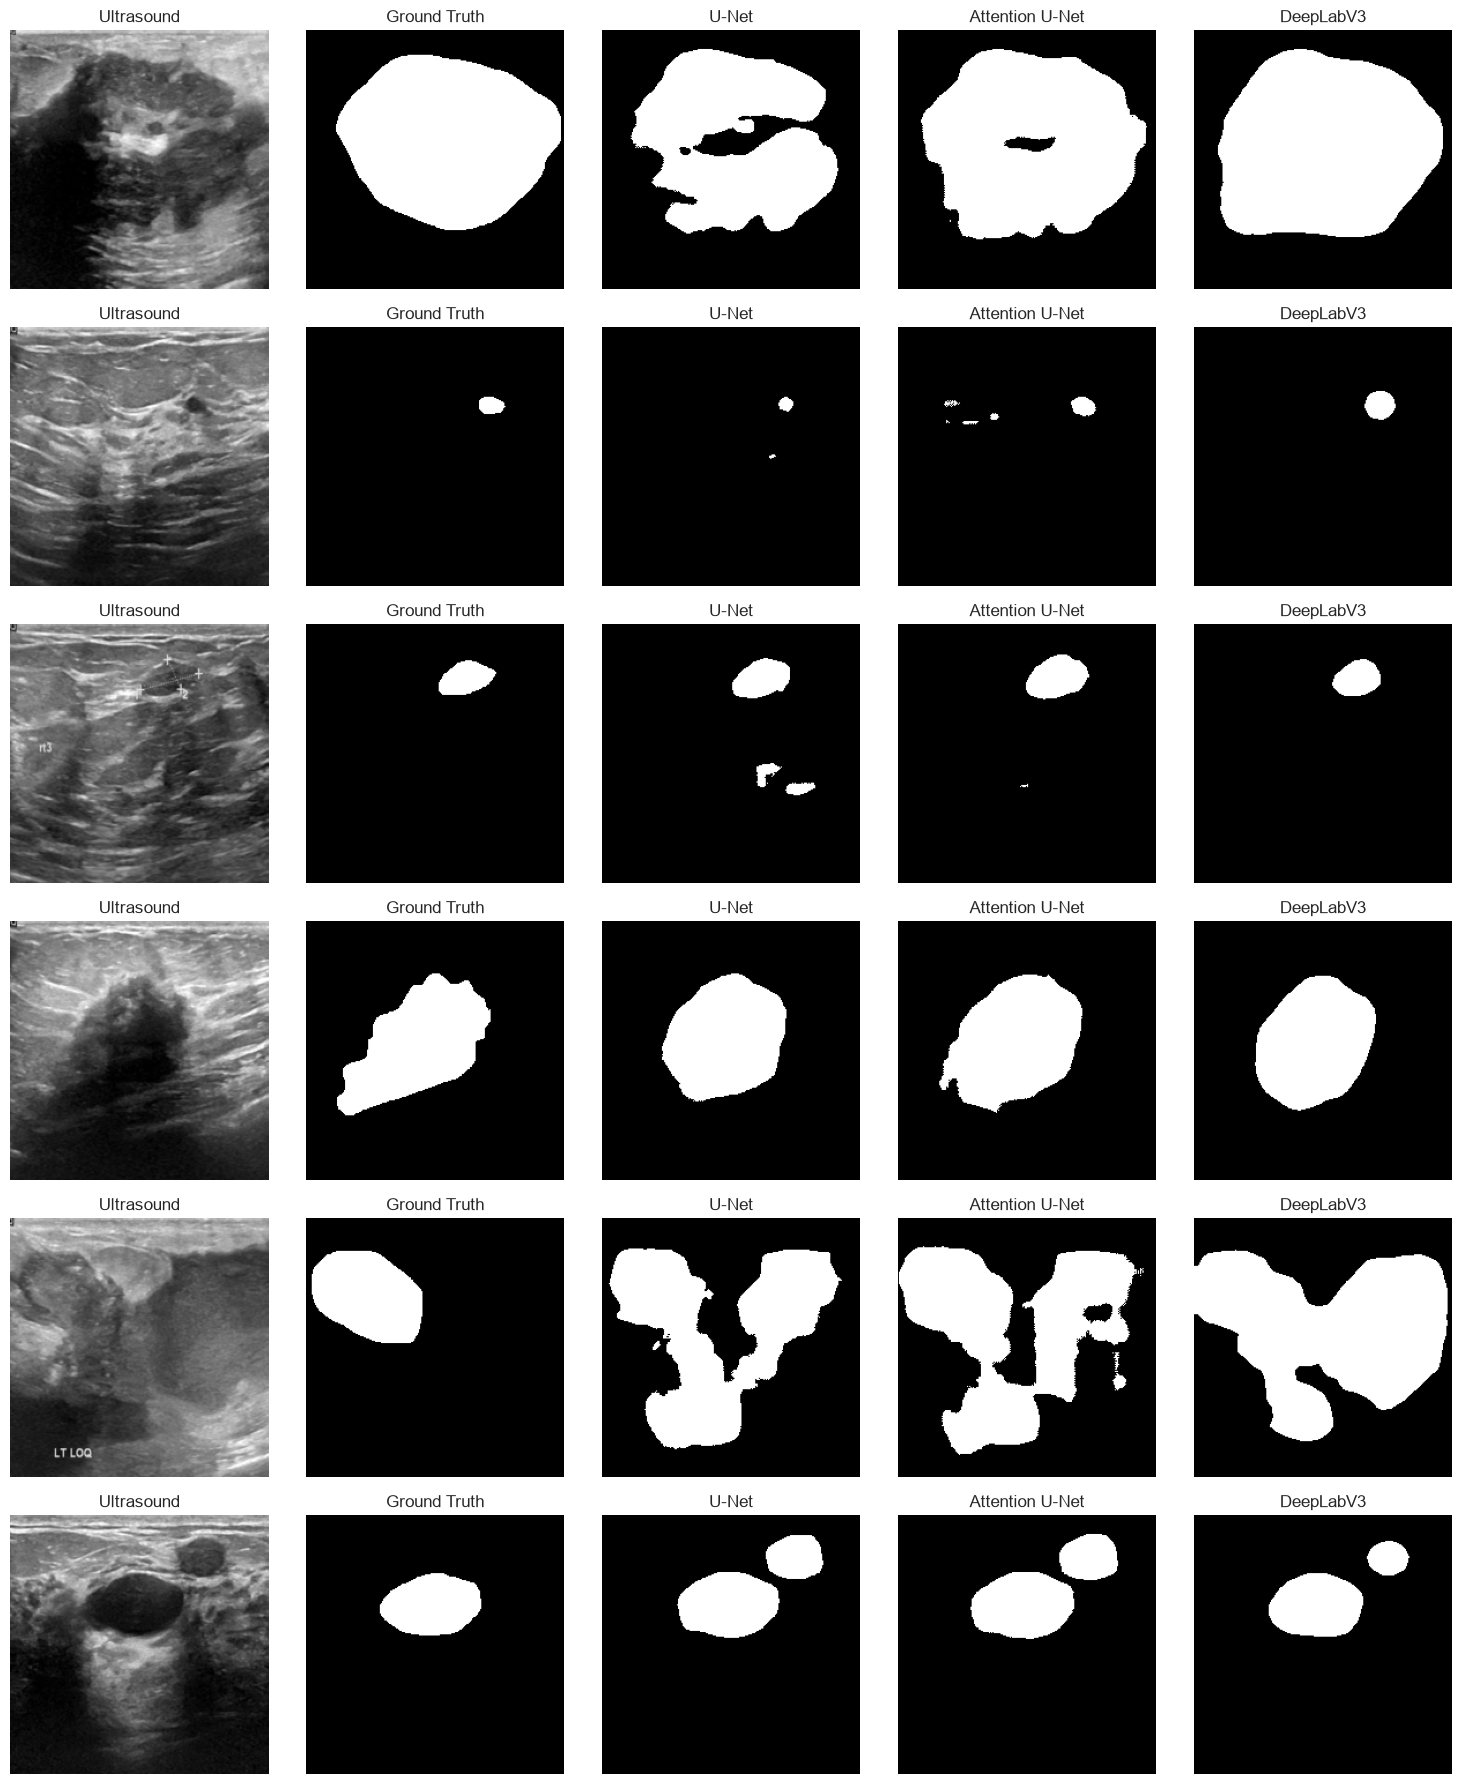

In [17]:
@torch.no_grad()
def show_segmentation_comparison(
    unet_model,
    attention_unet_model,
    deeplab_model,
    loader,
    max_samples=6,
    out_path=None,
):
    unet_model.eval()
    attention_unet_model.eval()
    deeplab_model.eval()

    images, masks = next(iter(loader))
    images = images[:max_samples].to(DEVICE)
    masks = masks[:max_samples]

    unet_preds = (
        torch.sigmoid(get_seg_logits(unet_model, images)) > 0.5
    ).float().cpu()

    attention_preds = (
        torch.sigmoid(get_seg_logits(attention_unet_model, images)) > 0.5
    ).float().cpu()

    deeplab_preds = (
        torch.sigmoid(get_seg_logits(deeplab_model, images)) > 0.5
    ).float().cpu()

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(1, 3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(1, 3, 1, 1)

    imgs = (images.cpu() * std + mean).clamp(0, 1)
    n = imgs.size(0)

    fig, axes = plt.subplots(
        n,
        5,
        figsize=(15, 3 * n),
    )

    if n == 1:
        axes = np.expand_dims(axes, 0)

    titles = [
        "Ultrasound",
        "Ground Truth",
        "U-Net",
        "Attention U-Net",
        "DeepLabV3",
    ]

    for i in range(n):
        axes[i, 0].imshow(imgs[i].permute(1, 2, 0).numpy())
        axes[i, 1].imshow(masks[i, 0].numpy(), cmap="gray")
        axes[i, 2].imshow(unet_preds[i, 0].numpy(), cmap="gray")
        axes[i, 3].imshow(attention_preds[i, 0].numpy(), cmap="gray")
        axes[i, 4].imshow(deeplab_preds[i, 0].numpy(), cmap="gray")

        for j in range(5):
            axes[i, j].set_title(titles[j])
            axes[i, j].axis("off")

    plt.tight_layout()

    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=150, bbox_inches="tight")

    plt.show()


best_unet = load_best_segmentation_model(
    "UNet",
    unet_experiment["best_path"],
)

best_attention_unet = load_best_segmentation_model(
    "AttentionUNet",
    attention_unet_experiment["best_path"],
)

best_deeplab = load_best_segmentation_model(
    "DeepLabV3-ResNet50",
    deeplab_experiment["best_path"],
)

show_segmentation_comparison(
    best_unet,
    best_attention_unet,
    best_deeplab,
    seg_loaders["test"],
    max_samples=6,
    out_path=FIGURE_DIR / "unet_attentionunet_deeplabv3_examples.png",
)


## 8. Inference Demo

Classification remains unchanged.  
For segmentation, choose either `UNet` or `DeepLabV3-ResNet50`.


=== U-Net segmentation demo ===


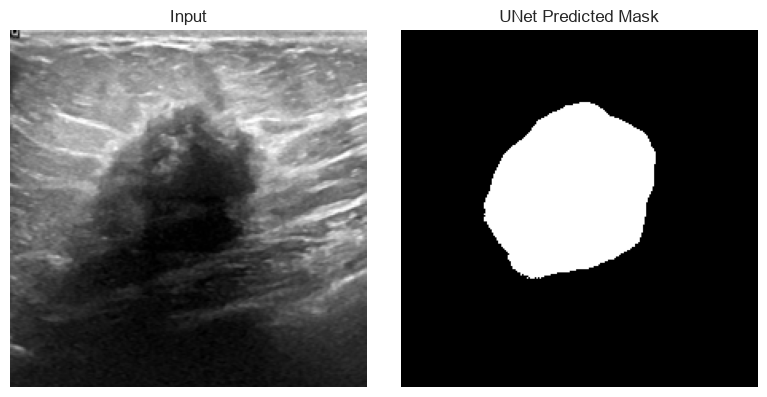


=== Attention U-Net segmentation demo ===


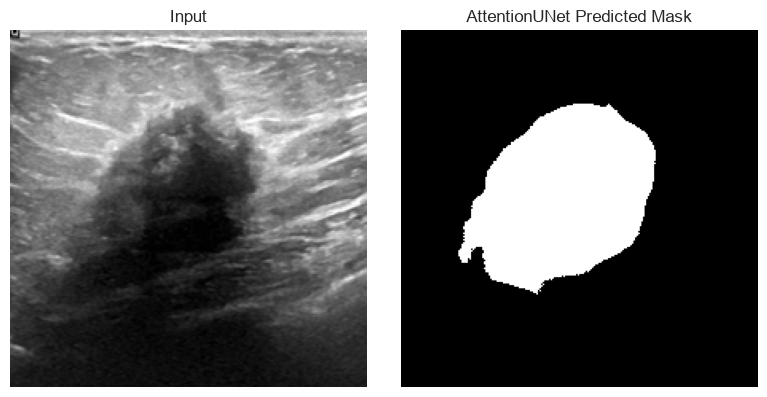


=== DeepLabV3 segmentation demo ===


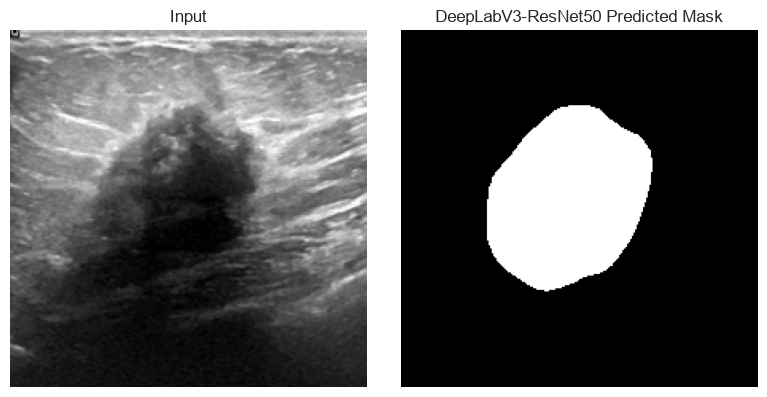

In [19]:
# def predict_class(image_path: Path, ckpt_path: Path = best_cls_path):
#     # Original classification inference: unchanged.
#     ckpt = torch.load(
#         ckpt_path,
#         map_location=DEVICE,
#         weights_only=False,
#     )

#     model = build_classifier(
#         ckpt.get("model_name", CLS_MODEL),
#         num_classes=3,
#     )

#     model.load_state_dict(ckpt["state_dict"])
#     model.to(DEVICE).eval()

#     x = ClassificationAugment()(
#         load_rgb(image_path),
#         train=False,
#     ).unsqueeze(0).to(DEVICE)

#     with torch.no_grad():
#         probs = torch.softmax(model(x), dim=1)[0]

#     pred = int(probs.argmax().item())

#     print(f"Image: {image_path}")
#     for i, name in enumerate(CLASS_NAMES):
#         print(f"  {name:10s}: {probs[i].item():.4f}")

#     print(f"Prediction: {CLASS_NAMES[pred]}")
#     return CLASS_NAMES[pred]


@torch.no_grad()
def predict_mask(
    image_path: Path,
    model_name: str,
    ckpt_path: Path,
):
    model = load_best_segmentation_model(
        model_name,
        ckpt_path,
    )

    image = load_rgb(image_path)

    tf = transforms.Compose([
        transforms.Resize(
            (IMG_SIZE, IMG_SIZE)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ])

    x = tf(image).unsqueeze(0).to(DEVICE)
    logits = get_seg_logits(model, x)

    pred = (
        torch.sigmoid(logits) > 0.5
    ).float().cpu()[0, 0].numpy()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(8, 4),
    )

    axes[0].imshow(
        image.resize((IMG_SIZE, IMG_SIZE))
    )
    axes[0].set_title("Input")
    axes[0].axis("off")

    axes[1].imshow(
        pred,
        cmap="gray",
    )
    axes[1].set_title(
        f"{model_name} Predicted Mask"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Example:
demo_malignant = next(
    s for s in split["test"]
    if s.class_name == "malignant"
).image_path

print("=== U-Net segmentation demo ===")
predict_mask(
    demo_malignant,
    model_name="UNet",
    ckpt_path=unet_experiment["best_path"],
)

print("\n=== Attention U-Net segmentation demo ===")
predict_mask(
    demo_malignant,
    model_name="AttentionUNet",
    ckpt_path=attention_unet_experiment["best_path"],
)

print("\n=== DeepLabV3 segmentation demo ===")
predict_mask(
    demo_malignant,
    model_name="DeepLabV3-ResNet50",
    ckpt_path=deeplab_experiment["best_path"],
)


## 9. Suggested Report Interpretation

### Classification
The classification section remains the original ResNet18 pipeline and can later be replaced by the optimal classification model selected by the teammate responsible for that task.

### Segmentation models
- **U-Net:** standard encoder-decoder architecture with direct skip connections.
- **Attention U-Net:** adds attention gates to skip connections to suppress irrelevant background and emphasize lesion-relevant features.
- **DeepLabV3-ResNet50:** uses atrous convolution and ASPP to capture multi-scale contextual information.

### Primary metrics
- Mean per-image Dice coefficient
- Mean per-image IoU
- Validation Dice for best-checkpoint selection

### Recommended qualitative analysis
Compare:
- small lesions
- large lesions
- irregular boundaries
- low-contrast lesions
- noisy ultrasound backgrounds
- over-segmentation
- under-segmentation

### Suggested research question
**How do standard skip connections, attention-gated skip connections, and multi-scale contextual feature extraction compare for breast lesion segmentation on BUSI ultrasound images?**

### Fair-comparison note
DeepLabV3 uses pretrained weights when available, while U-Net and Attention U-Net are trained from scratch. State this explicitly in the final report.
